# Potpuno povezana neuronska mreža

U ovoj svesci primenjuju se potpuno povezane neuronske mreže za predviđanje koncentracije PM2.5. Ispituje se više različitih arhitektura neuronske mreže kako bi se utvrdilo koja od njih ostvaruje najbolje performanse.

Modeli se porede na osnovu rezultata na validacionom skupu, dok se test skup koristi isključivo za konačnu evaluaciju najbolje izabrane arhitekture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import metrics
from sklearn import preprocessing
from sklearn import model_selection
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Učitavanje skupa podataka

In [3]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

# Pretprocesiranje podataka

In [4]:
data = data.drop(columns=['No'])
data = data.dropna(subset=['pm2.5'])
data = pd.get_dummies(data, columns=['cbwd'], dtype=int)

Ulazni atributi izdvajaju se u skup `x`, dok ciljnu promenljivu `y` predstavlja koncentracija PM2.5.

In [5]:
x = data.drop(columns=['pm2.5'])
y = data['pm2.5']

## Podela podataka 

Podaci se dele na trening, validacioni i test skup. Trening skup koristi se za obučavanje neuronskih mreža, validacioni skup za praćenje procesa obučavanja i poređenje različitih arhitektura, dok se test skup koristi za konačnu evaluaciju najbolje izabranog modela.

In [6]:
x_train_val, x_test, y_train_val, y_test = model_selection.train_test_split(x, y, test_size=0.33, random_state=7)

In [7]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_train_val, y_train_val, train_size=0.8, random_state=7)

## Standardizacija podataka

Pre obučavanja neuronskih mreža vrši se standardizacija ulaznih atributa kako bi se njihove vrednosti dovele na uporedivu skalu.

Parametri standardizacije određuju se isključivo na trening skupu, a zatim se isti parametri primenjuju na trening, validacioni i test skup. Na ovaj način se sprečava curenje informacija iz validacionog i test skupa u proces obučavanja modela.

In [8]:
scaler = preprocessing.StandardScaler()

In [9]:
scaler.fit(x_train)

StandardScaler()

In [10]:
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [11]:
number_of_features = x_train.shape[1]
output_size = 1

# Model 1

Prva ispitivana arhitektura predstavlja manju potpuno povezanu neuronsku mrežu sa dva skrivena sloja. Prvi skriveni sloj sadrži 32, a drugi 16 neurona. U skrivenim slojevima koristi se ReLU aktivaciona funkcija, dok izlazni sloj sadrži jedan neuron namenjen predviđanju kontinualne vrednosti koncentracije PM2.5.

Za funkciju greške koristi se srednja kvadratna greška (`mse`), dok se za optimizaciju parametara mreže koristi Adam optimizator.

In [12]:
model1 = Sequential([layers.Input(shape=(number_of_features,)),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(output_size)])

In [13]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model1.compile(loss='mse',optimizer='adam',metrics=['mae'])

## Obučavanje prve arhitekture

Prva arhitektura obučava se tokom 100 epoha. Tokom obučavanja prate se vrednosti funkcije greške i MAE metrike na trening i validacionom skupu.

In [15]:
history = model1.fit(x_train, y_train, epochs=100, batch_size=32,validation_data=(x_val, y_val),verbose=1)

Epoch 1/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 11374.4375 - mae: 72.6845 - val_loss: 6504.6353 - val_mae: 58.1932
Epoch 2/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6436.6118 - mae: 57.9948 - val_loss: 5821.6216 - val_mae: 55.1429
Epoch 3/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5937.3325 - mae: 55.4098 - val_loss: 5531.0596 - val_mae: 52.8963
Epoch 4/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5682.0332 - mae: 53.7018 - val_loss: 5328.8018 - val_mae: 51.7080
Epoch 5/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5485.9751 - mae: 52.4629 - val_loss: 5141.3970 - val_mae: 50.3859
Epoch 6/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5293.8491 - mae: 51.1787 - val_loss: 4949.2559 - val_mae: 49.4094
Epoch 7/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5099.9639 - mae: 49.9399 - val_loss: 4779.8862 - val_mae: 48.2766
Epoch 8/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4964.5210 - mae: 49.1812 - val_loss: 4659.6934 - 

Grafički prikaz trening i validacione greške omogućava praćenje procesa obučavanja prve arhitekture. Poređenjem ovih vrednosti može se proceniti kako se performanse modela menjaju tokom epoha i da li dolazi do značajnijeg razdvajanja rezultata trening i validacionog skupa.

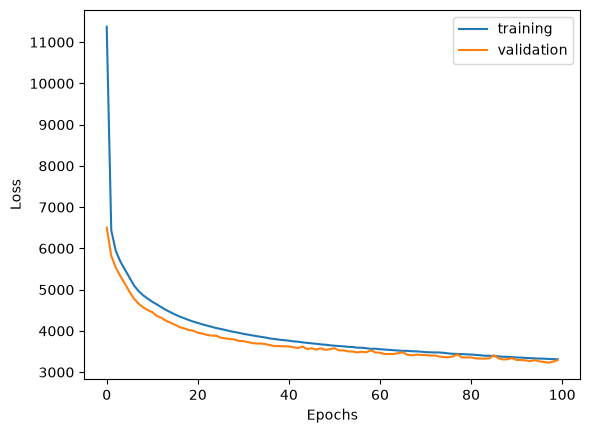

In [16]:
plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

Na grafikonu se može uočiti da trening i validaciona greška naglo opadaju tokom početnih epoha, nakon čega se smanjenje nastavlja sporijim tempom. Vrednosti trening i validacione greške ostaju relativno bliske tokom obučavanja i ne dolazi do njihovog izraženog razdvajanja.

Na osnovu ovakvog kretanja greške ne uočava se izraženo preprilagođavanje modela trening podacima.

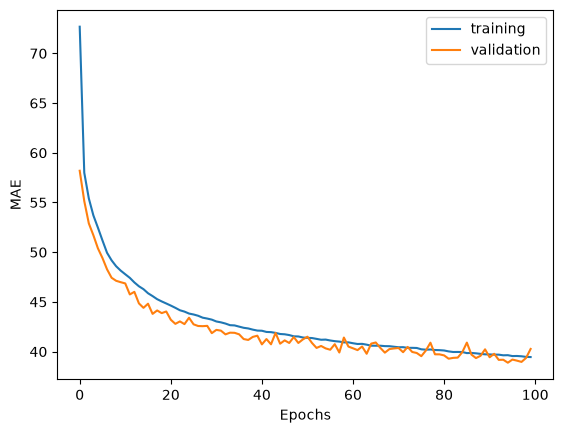

In [17]:
plt.plot(history.history['mae'], label='training')
plt.plot(history.history['val_mae'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend(loc='best')
plt.show()

Sličan obrazac može se uočiti i kod MAE vrednosti. Greška se značajno smanjuje tokom početnih epoha, dok se kasnije smanjuje sporije uz manje oscilacije na validacionom skupu.

Trening i validaciona MAE vrednost ostaju približne, što ukazuje da prva arhitektura zadržava slične performanse na trening i validacionim podacima.

In [18]:
y_val_predicted1 = model1.predict(x_val)

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [19]:
r2_1 = metrics.r2_score(y_val, y_val_predicted1)

In [20]:
mae_1 = metrics.mean_absolute_error(y_val, y_val_predicted1)

In [21]:
rmse_1 = np.sqrt(metrics.mean_squared_error(y_val, y_val_predicted1))

In [22]:
print('Model 1')
print('R2:', r2_1)
print('MAE:', mae_1)
print('RMSE:', rmse_1)

Model 1
R2: 0.5880490727110883
MAE: 40.268059250912636
RMSE: 57.37243677419022


Prva arhitektura na validacionom skupu ostvaruje R² vrednost od približno 0,588, MAE od 40,27 i RMSE od 57,37.

Model objašnjava približno 59% varijabilnosti ciljne promenljive. Dobijeni rezultati predstavljaju osnovu za poređenje sa složenijim arhitekturama neuronske mreže.

# Model 2

Druga arhitektura takođe sadrži dva skrivena sloja, ali sa većim brojem neurona. Prvi skriveni sloj sadrži 64, a drugi 32 neurona. Povećanjem broja neurona ispituje se da li mreža većeg kapaciteta može bolje da modeluje složene odnose između ulaznih atributa i koncentracije PM2.5.

In [23]:
model2 = Sequential([layers.Input(shape=(number_of_features,)),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(output_size)])

In [24]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model2.compile(loss='mse',optimizer='adam',metrics=['mae'])

In [26]:
history2 = model2.fit(x_train, y_train, epochs=100, batch_size=32,validation_data=(x_val, y_val),verbose=1)

Epoch 1/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 9329.8779 - mae: 66.8814 - val_loss: 6063.1807 - val_mae: 56.4352
Epoch 2/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6017.9697 - mae: 55.9970 - val_loss: 5439.1895 - val_mae: 53.0986
Epoch 3/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5519.3774 - mae: 52.8109 - val_loss: 5071.0913 - val_mae: 50.8888
Epoch 4/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 5213.0151 - mae: 50.9684 - val_loss: 4827.0503 - val_mae: 48.6890
Epoch 5/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5036.7056 - mae: 49.8978 - val_loss: 4741.0264 - val_mae: 49.4080
Epoch 6/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4903.3735 - mae: 49.1473 - val_loss: 4575.9634 - val_mae: 47.7851
Epoch 7/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4789.2671 - mae: 48.4132 - val_loss: 4476.3203 - val_mae: 46.7394
Epoch 8/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4677.4873 - mae: 47.7621 - val_loss: 4386.7935 - v

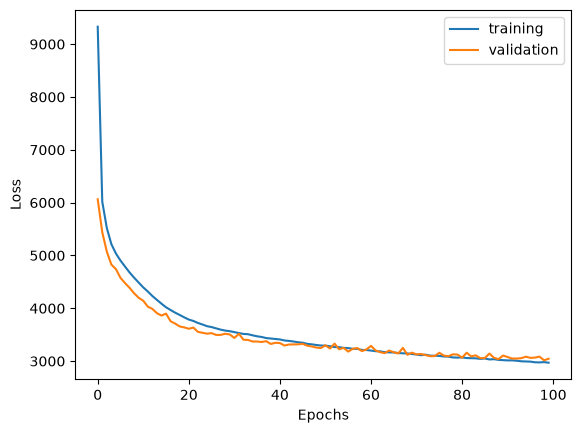

In [27]:
plt.plot(history2.history['loss'], label='training')
plt.plot(history2.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

Kod druge arhitekture takođe se uočava izraženo smanjenje trening i validacione greške tokom obučavanja. Nakon početnog bržeg pada, greška nastavlja postepeno da se smanjuje uz određene oscilacije na validacionom skupu.

Trening i validaciona greška ostaju relativno bliske, bez izraženog razdvajanja koje bi ukazivalo na značajno preprilagođavanje modela.


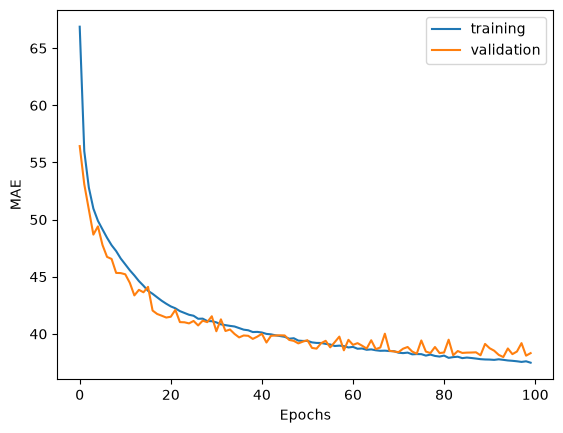

In [28]:
plt.plot(history2.history['mae'], label='training')
plt.plot(history2.history['val_mae'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend(loc='best')
plt.show()

MAE vrednosti druge arhitekture pokazuju sličan trend kao funkcija greške. Tokom obučavanja dolazi do postepenog smanjenja greške i na trening i na validacionom skupu.

U odnosu na prvu arhitekturu, druga mreža postiže niže vrednosti greške, što ukazuje da povećanje broja neurona doprinosi boljim performansama modela.

In [29]:
y_val_predicted2 = model2.predict(x_val)

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [30]:
r2_2 = metrics.r2_score(y_val, y_val_predicted2)
mae_2 = metrics.mean_absolute_error(y_val, y_val_predicted2)
rmse_2 = np.sqrt(metrics.mean_squared_error(y_val, y_val_predicted2))

In [31]:
print('Model 2')
print('R2:', r2_2)
print('MAE:', mae_2)
print('RMSE:', rmse_2)

Model 2
R2: 0.618950240062248
MAE: 38.31917591214851
RMSE: 55.17869179825695


Druga arhitektura na validacionom skupu ostvaruje R² vrednost od približno 0.619, MAE od 38.32 i RMSE od 55.18.

U odnosu na prvu arhitekturu, druga mreža ostvaruje veću R² vrednost i niže MAE i RMSE vrednosti. Povećanje broja neurona dovelo je do poboljšanja performansi modela.

# Model 3

Treća ispitivana arhitektura predstavlja najdublju i najsloženiju od tri neuronske mreže. Sadrži tri skrivena sloja sa 128, 64 i 32 neurona. Ovom arhitekturom ispituje se da li povećanje dubine i broja neurona omogućava uspešnije modelovanje složenih i nelinearnih odnosa prisutnih u podacima.

In [32]:
model3 = Sequential([layers.Input(shape=(number_of_features,)),
                     Dense(128, activation='relu'),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(output_size)])

In [33]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model3.compile(loss='mse',optimizer='adam',metrics=['mae'])

In [35]:
history3 = model3.fit(x_train, y_train, epochs=100, batch_size=32,validation_data=(x_val, y_val),verbose=1)

Epoch 1/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 7237.7393 - mae: 60.1969 - val_loss: 5127.2739 - val_mae: 50.7375
Epoch 2/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5152.3608 - mae: 50.1496 - val_loss: 4712.1582 - val_mae: 48.4892
Epoch 3/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 4769.6836 - mae: 47.8163 - val_loss: 4323.9824 - val_mae: 45.0514
Epoch 4/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4428.4277 - mae: 45.5879 - val_loss: 4017.9238 - val_mae: 43.1053
Epoch 5/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4172.4136 - mae: 44.0084 - val_loss: 3978.8228 - val_mae: 44.4266
Epoch 6/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3986.5515 - mae: 42.7970 - val_loss: 3876.1309 - val_mae: 41.1800
Epoch 7/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 3856.5078 - mae: 41.9637 - val_loss: 3668.0969 - val_mae: 40.8768
Epoch 8/100
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 3744.7395 - mae: 41.2222 - val_loss: 3643.5002 - v

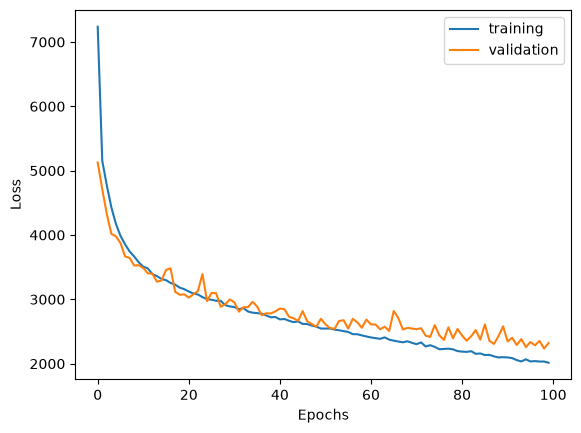

In [36]:
plt.plot(history3.history['loss'], label='training')
plt.plot(history3.history['val_loss'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

Kod treće, najsloženije arhitekture, trening i validaciona greška takođe opadaju tokom obučavanja. Validaciona greška pokazuje određene oscilacije između epoha, ali ne dolazi do njenog kontinuiranog povećavanja u odnosu na trening grešku.

Na osnovu grafikona ne uočava se izraženo preprilagođavanje, dok niže vrednosti greške u odnosu na prethodne arhitekture ukazuju na bolje performanse ove mreže.

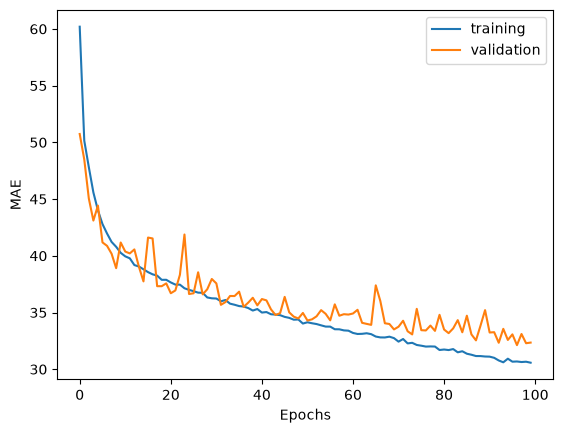

In [37]:
plt.plot(history3.history['mae'], label='training')
plt.plot(history3.history['val_mae'], label='validation')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend(loc='best')
plt.show()

MAE vrednosti se tokom obučavanja postepeno smanjuju, pri čemu trening i validaciona kriva ostaju relativno bliske. Validaciona MAE pokazuje manje oscilacije, ali se ne uočava trend njenog značajnog pogoršavanja.

U poređenju sa prethodne dve arhitekture, treća mreža postiže najniže vrednosti greške, što ukazuje da veći broj neurona i dodatni skriveni sloj omogućavaju uspešnije modelovanje odnosa u podacima.

In [38]:
y_val_predicted3 = model3.predict(x_val)

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
r2_3 = metrics.r2_score(y_val, y_val_predicted3)
mae_3 = metrics.mean_absolute_error(y_val, y_val_predicted3)
rmse_3 = np.sqrt(metrics.mean_squared_error(y_val, y_val_predicted3))

In [40]:
print('Model 3')
print('R2:', r2_3)
print('MAE:', mae_3)
print('RMSE:', rmse_3)

Model 3
R2: 0.7095240775238727
MAE: 32.348280717915
RMSE: 48.17654192158399


Treća arhitektura na validacionom skupu ostvaruje R² vrednost od približno 0.710, MAE od 32.35 i RMSE od 48.18.

Ova arhitektura ostvaruje najbolje rezultate od sve tri ispitane mreže prema svim posmatranim metrikama. Model objašnjava približno 71% varijabilnosti ciljne promenljive, dok su MAE i RMSE dodatno smanjeni u odnosu na prethodne dve arhitekture.

Rezultati pokazuju da je povećanje složenosti neuronske mreže u ovom slučaju dovelo do poboljšanja sposobnosti modela da predviđa koncentraciju PM2.5.

# Poređenje arhitektura neuronske mreže

Nakon obučavanja sve tri arhitekture porede se njihove R², MAE i RMSE vrednosti na validacionom skupu.

Za izbor najboljeg modela kao osnovni kriterijum koristi se R² vrednost. Najboljom se smatra arhitektura koja ostvaruje najveću R² vrednost na validacionom skupu.

In [41]:
results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'R2': [r2_1, r2_2, r2_3],
    'MAE': [mae_1, mae_2, mae_3],
    'RMSE': [rmse_1, rmse_2, rmse_3]
                       })
results

,Model,R2,MAE,RMSE
0,Model 1,0.588049,40.268059,57.372437
1,Model 2,0.618950,38.319176,55.178692
2,Model 3,0.709524,32.348281,48.176542


Poređenjem rezultata može se uočiti postepeno poboljšanje performansi sa povećanjem složenosti neuronske mreže.

Prva arhitektura ostvaruje R² od približno 0.588, druga 0.619, dok treća arhitektura ostvaruje najveću R² vrednost od približno 0.710. Istovremeno se MAE smanjuje sa 40.27 na 32.35, a RMSE sa 57.37 na 48.18.

Na osnovu sve tri posmatrane metrike, treća arhitektura ostvaruje najbolje performanse na validacionom skupu.

## Izbor najbolje arhitekture

Na osnovu rezultata na validacionom skupu bira se arhitektura sa najvećom R² vrednošću. Na ovaj način test skup ne učestvuje u izboru arhitekture, već ostaje nezavisan skup podataka za konačnu evaluaciju izabranog modela.

In [42]:
best_index = np.argmax([r2_1, r2_2, r2_3])

models = [model1, model2, model3]
best_model = models[best_index]

print('Najbolji model:', ['Model 1', 'Model 2', 'Model 3'][best_index])

Najbolji model: Model 3


Na osnovu R² vrednosti na validacionom skupu kao najbolja je izabrana treća arhitektura neuronske mreže.

Test skup nije korišćen prilikom poređenja i izbora arhitektura, već se koristi isključivo za konačnu evaluaciju izabranog modela.

# Evaluacija najbolje neuronske mreže

Nakon izbora najbolje arhitekture, njene performanse procenjuju se na test skupu. Test skup nije korišćen prilikom izbora arhitekture i zbog toga omogućava konačnu procenu sposobnosti modela da predviđa koncentraciju PM2.5 na novim podacima.

In [43]:
y_test_predicted = best_model.predict(x_test)

431/431 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [45]:
print('Potpuno povezana neuronska mreža - TEST')
print('R2:', metrics.r2_score(y_test, y_test_predicted))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_predicted))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_predicted)))

Potpuno povezana neuronska mreža - TEST
R2: 0.696601027736018
MAE: 33.48608207066796
RMSE: 51.44243085704403


Najbolja neuronska mreža na test skupu ostvaruje R² vrednost od približno 0.697, MAE od 33.49 i RMSE od 51.44.

Model objašnjava približno 70% varijabilnosti ciljne promenljive. R² vrednost na test skupu nešto je niža od vrednosti ostvarene na validacionom skupu, dok su MAE i RMSE nešto veći.

Razlika između rezultata na validacionom i test skupu nije velika, što ukazuje da izabrana neuronska mreža zadržava dobre performanse i na podacima koji nisu korišćeni tokom treniranja i izbora modela.

# Čuvanje modela i scaler-a

In [46]:
import joblib

In [47]:
best_model.save("../models/06_NeuralNetwork.keras")

In [49]:
joblib.dump(scaler, "../models/06_scaler.pkl")

['../models/06_scaler.pkl']